In [2]:
import numpy as np
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
import matplotlib.pyplot as plt

In [3]:
SCENE = 'test2'
pol = "hh"

In [4]:
if SCENE == 'desert':
    SLC_PATH = f"data/Biomass_data/desert_scene/BIO_dessert.{pol}.slc"
    SLC_PAR_PATH = f"data/Biomass_data/desert_scene/BIO_dessert.{pol}.slc.par"
    ANNOT_XML = "data/Biomass_data/desert_scene/BIO_S2_SCS__1S_20260202T174434_20260202T174457_T_G01_M01_CDR_T026_F137_01_DMKLZR/annotation/bio_s2_scs__1s_20260202t174434_20260202t174457_t_g01_m01_cdr_t026_f137_annot.xml"

    SLC_RFI_PATH = f"data/Biomass_data/desert_scene/rfi1_filtered_desert_{pol}.slc"

elif SCENE == 'ocean':
    SLC_PATH = "data/Biomass_data/ocean_scene/20260204.hh.slc"
    SLC_PAR_PATH = "data/Biomass_data/ocean_scene/20260204.hh.slc.par"
    ANNOT_XML = "data/Biomass_data/ocean_scene/BIO_S2_SCS__1S_20260204T154918_20260204T154941_T_G01_M01_CDR_T010_F183_01_DMKHUB/annotation/bio_s2_scs__1s_20260204t154918_20260204t154941_t_g01_m01_cdr_t010_f183_annot.xml"

    SLC_RFI_PATH = 'data/Biomass_data/ocean_scene/20260204_rfi1.slc'

elif SCENE == 'test':
    SLC_PATH = "data/Biomass_data/Test_Scene/20260216.hh.slc"
    SLC_PAR_PATH = "data/Biomass_data/Test_Scene/20260216.hh.slc.par"
    ANNOT_XML = "data/Biomass_data/Test_Scene/BIO_S1_SCS__1S_20260216T155114_20260216T155133_T_G01_M02_C03_T010_F182_01_DMY9IM/annotation/bio_s1_scs__1s_20260216t155114_20260216t155133_t_g01_m02_c03_t010_f182_annot.xml"

    SLC_RFI_PATH = 'data/Biomass_data/Test_Scene/20260216_rfi1.slc'

elif SCENE == 'test2':
    SLC_PATH = "data/Biomass_data/test2/20260206.hh.slc"
    SLC_PAR_PATH = "data/Biomass_data/test2/20260206.hh.slc.par"
    ANNOT_XML = "data/Biomass_data/test2/BIO_S2_SCS__1S_20260206T042117_20260206T042137_T_G01_M01_CDR_T032_F281_01_DMKUB5/annotation/bio_s2_scs__1s_20260206t042117_20260206t042137_t_g01_m01_cdr_t032_f281_annot.xml"

    #SLC_RFI_PATH = 'data/Biomass_data/Test_Scene/20260216_rfi1.slc'

In [5]:
# Windowing for CDE DC estimation
WIN_AZ = 512
WIN_RG = 100
STRIDE_AZ = 256
STRIDE_RG = 100

In [6]:
def iso_to_unix(iso_str: str) -> float:
    """
    Convert ISO8601 (no timezone) to unix seconds (assume UTC).
    Example: '2026-02-04T15:49:18.236719'
    """
    dt = datetime.fromisoformat(iso_str).replace(tzinfo=timezone.utc)
    
    return dt.timestamp()

def parse_slc_par(par_file):
    """
    Function to get parameters from GAMMA RS slc.par file into dictionary
    """
    params = {}
    with open(par_file, 'r') as f:
        for line in f:
            if ':' in line:
                key, _, val = line.partition(':')
                params[key.strip()] = val.strip().split()
    
    return params

def read_slc(slc_file, slc_par_file):
    """
    Function to read a GAMMA RS .slc file into an np.array image
    """
    par = parse_slc_par(slc_par_file)

    
    range_samples = int(par['range_samples'][0])
    azimuth_lines = int(par['azimuth_lines'][0])

    dt = np.dtype('>f4')
    raw = np.fromfile(slc_file, dtype=dt)
    complex_data = raw[0::2] + 1j * raw[1::2]

    return complex_data.reshape(azimuth_lines, range_samples)

def fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG):
    """
    Function to calculate the doppler centroids of an SLC image with FFT
    """

    slc = read_slc(SLC_PATH, SLC_PAR_PATH)
    dt_a = float(parse_slc_par(SLC_PAR_PATH)['azimuth_line_time'][0])

    n_rg = (slc.shape[1] - WIN_RG) // STRIDE_RG + 1
    n_az = (slc.shape[0] - WIN_AZ) // STRIDE_AZ + 1

    doppler_img = np.zeros((n_az*STRIDE_AZ, n_rg*STRIDE_RG))
    spectrum = np.empty((n_az,n_rg), dtype=object)

    freqs = np.fft.fftfreq(WIN_AZ, d=dt_a)
    freqs = np.fft.fftshift(freqs)

    for j in range(n_az):
        az_0 = j * STRIDE_AZ

        for i in range(n_rg):
            rg_0 = i * STRIDE_RG

            S = np.fft.fft(slc[az_0:az_0+WIN_AZ, rg_0:rg_0+WIN_RG], axis=0)
            S = np.fft.fftshift(S, axes=0) 
            S_abs = np.abs(S)**2
            P = np.sum(S_abs, axis=1)
            f_dc = np.sum(freqs * P) / np.sum(P)

            spectrum[j,i] = P
            doppler_img[j*STRIDE_AZ:(j+1)*STRIDE_AZ,i*STRIDE_RG:(i+1)*STRIDE_RG] = f_dc

    return doppler_img, freqs, spectrum

def CDE_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG):
    """
    Function to calculate the doppler centroids of an SLC image with CDE
    """
    slc = read_slc(SLC_PATH, SLC_PAR_PATH) 
    n_az = (slc.shape[0] - WIN_AZ) // STRIDE_AZ + 1
    n_rg = (slc.shape[1] - WIN_RG) // STRIDE_RG + 1

    dt_a = float(parse_slc_par(SLC_PAR_PATH)['azimuth_line_time'][0])
    F_az = 1.0 / dt_a

    doppler_img = np.zeros((n_az*STRIDE_AZ, n_rg*STRIDE_RG))

    for i in range(n_az):
        a0 = i * STRIDE_AZ
  
        for j in range(n_rg):
            r0 = j * STRIDE_RG

            patch = slc[a0:a0+WIN_AZ, r0:r0+WIN_RG]
            C = patch[1:, :] * np.conj(patch[:-1, :])
            R1 = np.mean(C)
            phi = np.angle(R1)
            
            test = -(F_az / (2.0*np.pi)) * phi
            doppler_img[i*STRIDE_AZ:(i+1)*STRIDE_AZ,j*STRIDE_RG:(j+1)*STRIDE_RG] = (F_az / (2.0*np.pi)) * phi

    return doppler_img

def get_dc_estimates(ANNOT_XML):
    """
    Function to get the doppler Parameters from BIOMASS annotation file.
    """
    dc_estimates = []
    root = ET.parse(ANNOT_XML).getroot()

    for dc in root.findall(".//dopplerParameters//dcEstimateList//dcEstimate"):
        az_iso = dc.findtext("azimuthTime")
        t0 = dc.findtext("t0")
        poly = dc.findtext("geometryDCPolynomial")

        if az_iso is None or t0 is None or poly is None:
            continue

        az_unix = iso_to_unix(az_iso)
        t0 = float(t0)
        coeffs = np.array([float(x) for x in poly.split()], dtype=np.float64)

        dc_estimates.append((az_unix, t0, coeffs))

    return dc_estimates

def estimate_geom_doppler(ANNOT_XML, doppler_img=None):
    """
    Estimates the Doppler effect induced by satellite geometry from doppler polynomials. If doppler centroid image of scene is given then geometry doppler is registered to the dc image.
    """
    root = ET.parse(ANNOT_XML).getroot()

    dc_estimates = get_dc_estimates(ANNOT_XML)

    slant_range_time_0 = float(root.findtext(".//firstSampleSlantRangeTime"))
    range_pixel_spacing = float(root.findtext(".//rangeTimeInterval"))
    n_samples = int(root.findtext(".//numberOfSamples"))
    n_lines = int(root.findtext(".//numberOfLines"))
    azimuth_time_0 = iso_to_unix(root.findtext(".//firstLineAzimuthTime"))
    azimuth_pixel_spacing = float(root.findtext(".//azimuthTimeInterval"))

    tau = slant_range_time_0 + np.arange(n_samples) * range_pixel_spacing

    if doppler_img is not None:
        geom_doppler_coregistered = np.full((n_lines, n_samples), 10000)

    geom_doppler = np.zeros((len(dc_estimates), tau.shape[0]))

    diff = dc_estimates[1][0] - dc_estimates[0][0]
    start_az_idx = 0
    check = False

    for i, entry in enumerate(dc_estimates):
        az_0 = entry[0]
        t0 = entry[1]
        c0, c1, c2, c3, c4 = entry[2]
        for j, t in enumerate(tau):
            geom_doppler[i, j] = c0 + c1 * (t-t0) + c2 * (t-t0)**2 + c3 * (t-t0)**3 + c4 * (t-t0)**4

        if doppler_img is not None:
            if np.abs(az_0 - azimuth_time_0) <= diff:
                check = True
            
            if check:
                az_idx = int((diff - (azimuth_time_0 - az_0)) // azimuth_pixel_spacing)
                geom_doppler_coregistered[start_az_idx:az_idx+1, :] = geom_doppler[i,:]
            
                start_az_idx = az_idx+1  

    if doppler_img is not None:
        geom_doppler_coregistered = geom_doppler_coregistered[0:doppler_img.shape[0], 0:doppler_img.shape[1]]

        return geom_doppler_coregistered
    
    else:
        return geom_doppler
        

In [9]:
dc_img_fft, freqs, spectrum = fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)
dc_rfi_img_fft, freqs_rfi, spectrum_rfi = dc_img_fft, freqs, spectrum

#dc_rfi_img_fft, freqs_rfi, spectrum_rfi = fft_doppler(SLC_RFI_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)

dc_rfi_img_cde = CDE_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)
#dc_rfi_img_cde = CDE_doppler(SLC_RFI_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)

In [10]:
geom_doppler = estimate_geom_doppler(ANNOT_XML)
geom_doppler_coregistered = estimate_geom_doppler(ANNOT_XML, dc_rfi_img_fft)

In [11]:
diff_dop = dc_img_fft - geom_doppler_coregistered
diff_dop_rfi = dc_rfi_img_fft - geom_doppler_coregistered

diff_dop_rfi_cde = dc_rfi_img_cde - geom_doppler_coregistered

FileNotFoundError: [Errno 2] No such file or directory: 'plots/test2/spectrum.png'

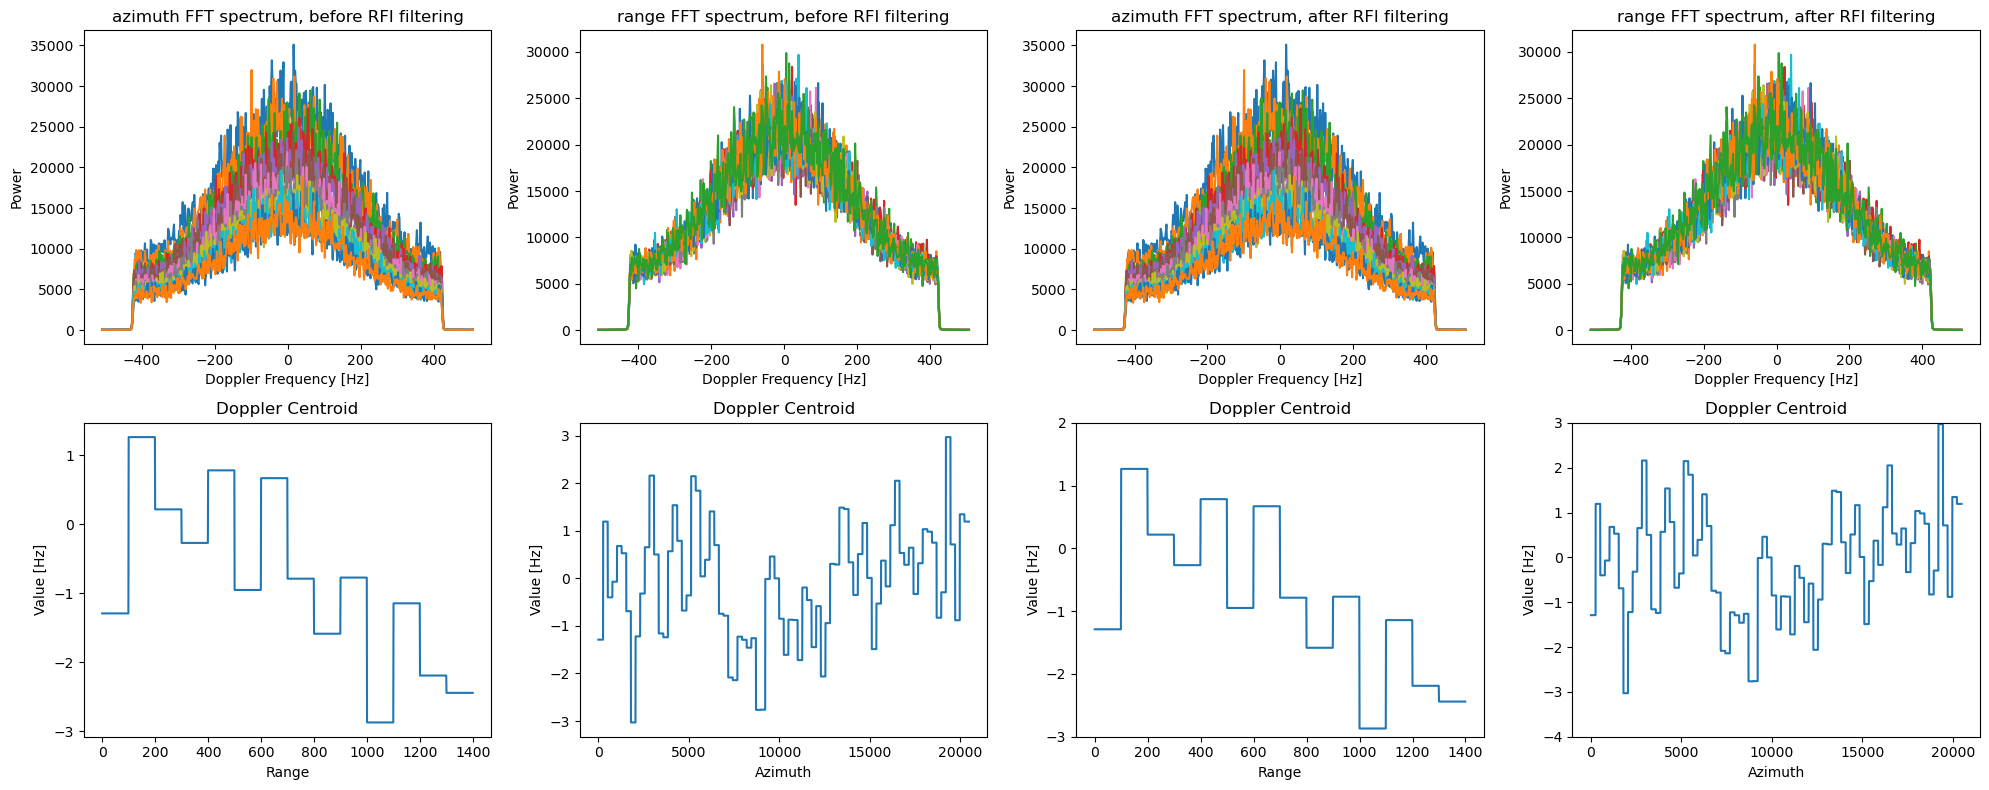

In [12]:
fig,ax = plt.subplots(2,4, figsize=(20,8))
ax = ax.flatten()

for i in np.arange(1,13):
    ax[0].plot(freqs, spectrum[1,i])
ax[0].set_title("azimuth FFT spectrum, before RFI filtering")
ax[0].set_xlabel("Doppler Frequency [Hz]")
ax[0].set_ylabel("Power")

for i in np.arange(31,44):
    ax[1].plot(freqs, spectrum[i,5])
ax[1].set_title("range FFT spectrum, before RFI filtering")
ax[1].set_xlabel("Doppler Frequency [Hz]")
ax[1].set_ylabel("Power")

for i in np.arange(1,13):
    ax[2].plot(freqs_rfi, spectrum_rfi[1,i])
ax[2].set_title("azimuth FFT spectrum, after RFI filtering")
ax[2].set_xlabel("Doppler Frequency [Hz]")
ax[2].set_ylabel("Power")

for i in np.arange(31,44):
    ax[3].plot(freqs_rfi, spectrum_rfi[i,5])
ax[3].set_title("range FFT spectrum, after RFI filtering")
ax[3].set_xlabel("Doppler Frequency [Hz]")
ax[3].set_ylabel("Power")

ax[4].plot(dc_img_fft[0])
ax[4].set_title("Doppler Centroid")
ax[4].set_xlabel("Range")
ax[4].set_ylabel("Value [Hz]")
ax[6].set_ylim([np.floor(np.min(dc_img_fft[0])), np.ceil(np.max(dc_img_fft[0]))])

ax[5].plot(dc_img_fft[:,5])
ax[5].set_title("Doppler Centroid")
ax[5].set_xlabel("Azimuth")
ax[5].set_ylabel("Value [Hz]")
ax[7].set_ylim([np.floor(np.min(dc_img_fft[:,5])), np.ceil(np.max(dc_img_fft[:,5]))])

ax[6].plot(dc_rfi_img_fft[0])
ax[6].set_title("Doppler Centroid")
ax[6].set_xlabel("Range")
ax[6].set_ylabel("Value [Hz]")
ax[6].set_ylim([np.floor(np.min(dc_rfi_img_fft[0])), np.ceil(np.max(dc_rfi_img_fft[0]))])

ax[7].plot(dc_rfi_img_fft[:,5])
ax[7].set_title("Doppler Centroid")
ax[7].set_xlabel("Azimuth")
ax[7].set_ylabel("Value [Hz]")
ax[7].set_ylim([np.floor(np.min(dc_rfi_img_fft[:,5])), np.ceil(np.max(dc_rfi_img_fft[:,5]))])

plt.tight_layout()
plt.savefig(f'plots/{SCENE}/spectrum.png' if SCENE != "desert" else f'plots/{SCENE}/{pol}/spectrum.png')

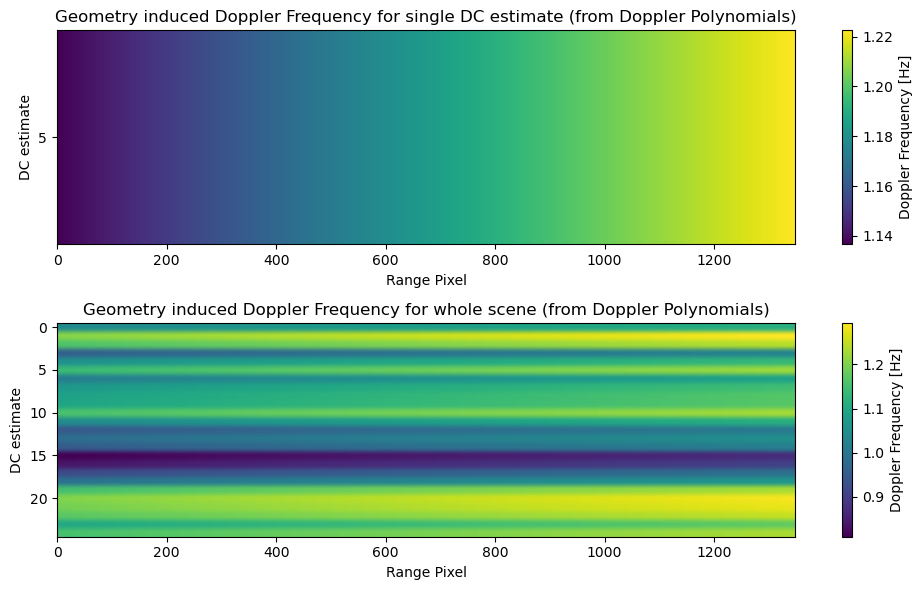

In [17]:
fig,ax = plt.subplots(2,1, figsize=(10,6))

im1 = ax[0].imshow(geom_doppler[5:6], aspect='auto')
ax[0].set_title("Geometry induced Doppler Frequency for single DC estimate (from Doppler Polynomials)")
ax[0].set_xlabel("Range Pixel")
ax[0].set_yticks([0])
ax[0].set_yticklabels([5])
ax[0].set_ylabel("DC estimate")
plt.colorbar(im1, ax=ax[0], label="Doppler Frequency [Hz]")

im2 = ax[1].imshow(geom_doppler, aspect='auto')
ax[1].set_title("Geometry induced Doppler Frequency for whole scene (from Doppler Polynomials)")
ax[1].set_xlabel("Range Pixel")
ax[1].set_ylabel("DC estimate")
plt.colorbar(im2, ax=ax[1], label="Doppler Frequency [Hz]")

plt.tight_layout()
plt.savefig(f'plots/{SCENE}/spectrum.png' if SCENE != "desert" else f'plots/{SCENE}/{pol}/geometry.png')

In [18]:
def plot_dc_maps(img, ax, title, cmap='viridis_r'):
    """
    Create plots for doppler centroid maps
    """
    vmin = np.round(np.quantile(img, 0.05))
    vmax = np.round(np.quantile(img, 0.95))
    im = ax.imshow(img, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap)

    ax.set_ylabel('azimuth')
    ax.set_xlabel(f'range\n median: {np.median(img):.2f}, MAD: {np.nanmedian(np.abs(img - np.nanmedian(img))):.2f}\n mean: {np.mean(img):.2f}, std: {np.std(img):.2f}')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='DC [Hz]')

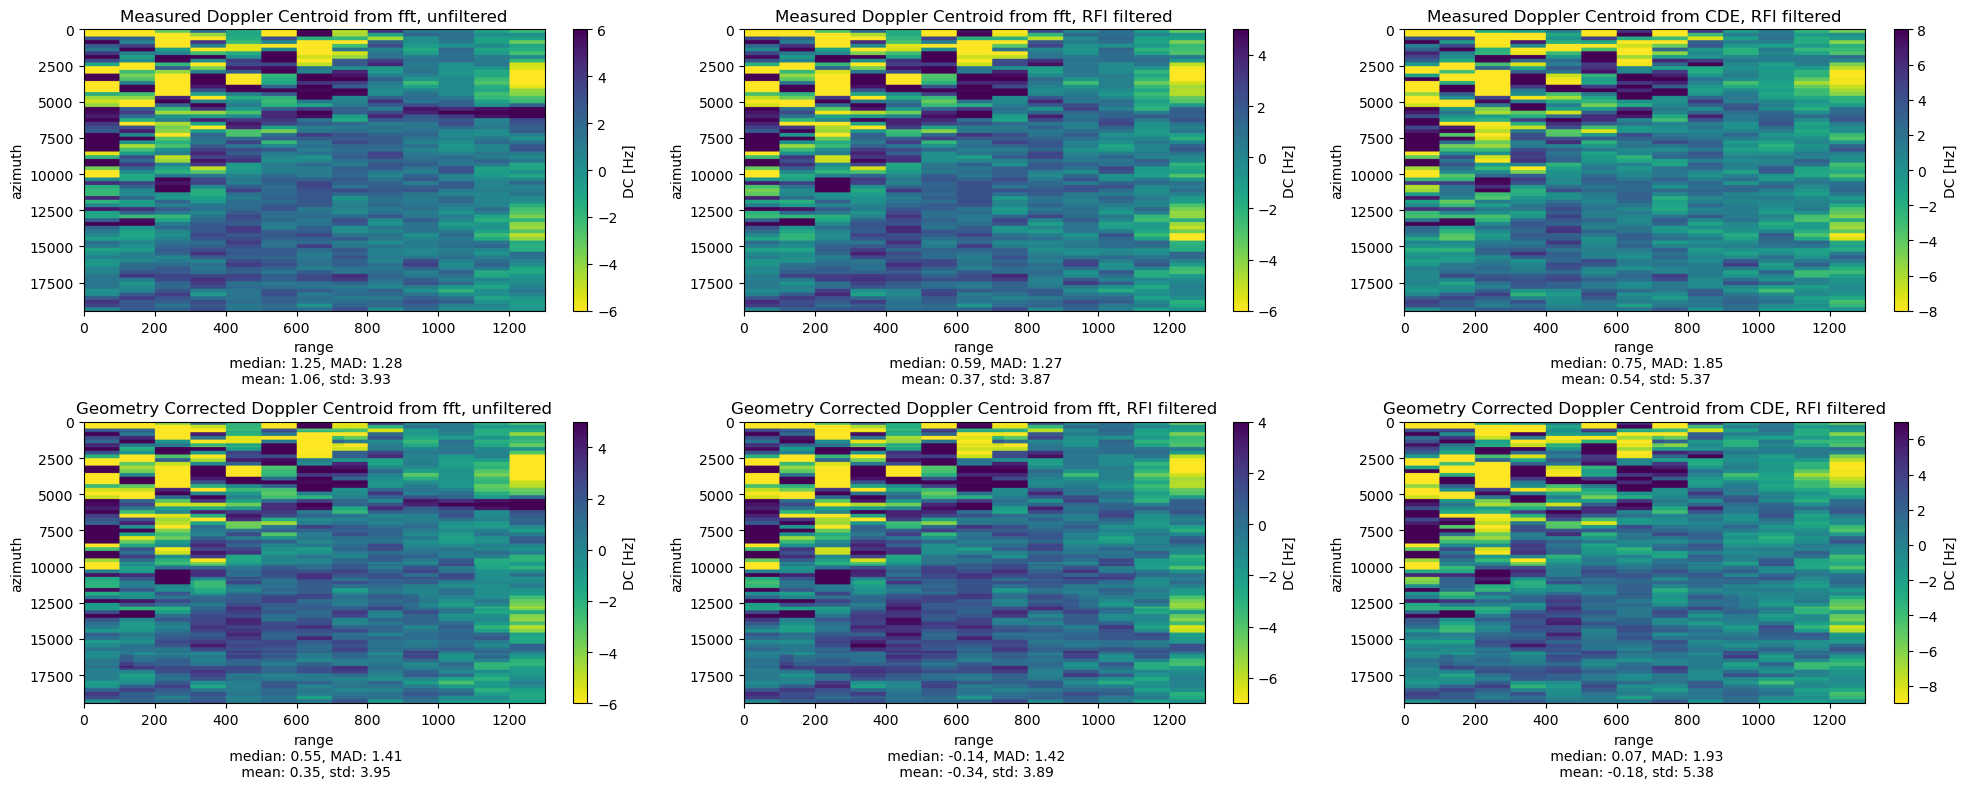

In [19]:
fig,ax = plt.subplots(2,3, figsize=(20,8))
ax = ax.flatten()

plot_dc_maps(dc_img_fft, ax[0], 'Measured Doppler Centroid from fft, unfiltered')
plot_dc_maps(dc_rfi_img_fft, ax[1], 'Measured Doppler Centroid from fft, RFI filtered')
plot_dc_maps(dc_rfi_img_cde, ax[2], 'Measured Doppler Centroid from CDE, RFI filtered')
plot_dc_maps(diff_dop, ax[3], 'Geometry Corrected Doppler Centroid from fft, unfiltered')
plot_dc_maps(diff_dop_rfi, ax[4], 'Geometry Corrected Doppler Centroid from fft, RFI filtered')
plot_dc_maps(diff_dop_rfi_cde, ax[5], 'Geometry Corrected Doppler Centroid from CDE, RFI filtered')

plt.tight_layout()
plt.savefig(f'plots/{SCENE}/spectrum.png' if SCENE != "desert" else f'plots/{SCENE}/{pol}/DCA.png')

In [14]:
def spectral_snr(P, noise_fraction=0.1):                                                                                                                                                                                  
      """                                                                                                                                                                                                                   
      Estimate spectral SNR from a 1D azimuth power spectrum P.                                                                                                                                                             
      noise_fraction: fraction of lowest-power bins used to estimate the noise floor.                                                                                                                                       
      Returns SNR (linear) and noise floor.
      """                                                                                                                                                                                                                   
      n_noise = max(1, int(noise_fraction * len(P)))
      noise_floor = np.mean(np.sort(P)[:n_noise])                                                                                                                                                                           
      peak = np.max(P)                                                                                                                                                                                                      
      snr = (peak - noise_floor) / noise_floor                                                                                                                                                                              
      return snr, noise_floor                                                                                                                                                                                               
                                                                                                                                                                                                                            
def dc_precision(snr, prf, win_az, win_rg):
    """                                                                                                                                                                                                                   
    Theoretical std of the DC centroid estimate [Hz].
    Derived from the Cramér–Rao bound for the weighted centroid estimator.                                                                                                                                                
    snr: spectral SNR (linear, from spectral_snr)                                                                                                                                                                         
    prf: pulse repetition frequency [Hz] = 1/dt_a                                                                                                                                                                         
    win_az, win_rg: window sizes used in fft_doppler                                                                                                                                                                      
    """                                                                                                                                                                                                                   
    delta_f = prf / win_az          # frequency resolution [Hz]
    # noise on each spectral bin ~ 1/sqrt(win_rg) (averaged over range pixels)                                                                                                                                            
    # DC std ≈ delta_f / sqrt(2 * snr * win_rg)                                                                                                                                                                           
    return delta_f / np.sqrt(2 * snr * win_rg)  

In [15]:
dt_a = float(parse_slc_par(SLC_PAR_PATH)['azimuth_line_time'][0])
prf = 1.0 / dt_a

In [16]:
# Pick a representative window, e.g. middle of scene
P_example = spectrum_rfi[spectrum_rfi.shape[0]//2, spectrum_rfi.shape[1]//2]
snr, noise_floor = spectral_snr(P_example)
sigma_dc = dc_precision(snr, prf, WIN_AZ, WIN_RG)

print(f"Spectral SNR:       {snr:.1f} ({10*np.log10(snr):.1f} dB)")
print(f"DC estimate std:    {sigma_dc:.3f} Hz")
print(f"Expected DCA:       ??? Hz")   # plug in your expected DCA

Spectral SNR:       1071.4 (30.3 dB)
DC estimate std:    0.004 Hz
Expected DCA:       ??? Hz


In [17]:
snr_map = np.zeros_like(dc_rfi_img_fft)
for j in range(spectrum_rfi.shape[0]):
    for i in range(spectrum_rfi.shape[1]):
        snr_val, _ = spectral_snr(spectrum_rfi[j, i])
        snr_map[j*STRIDE_AZ:(j+1)*STRIDE_AZ, i*STRIDE_RG:(i+1)*STRIDE_RG] = 10*np.log10(snr_val)

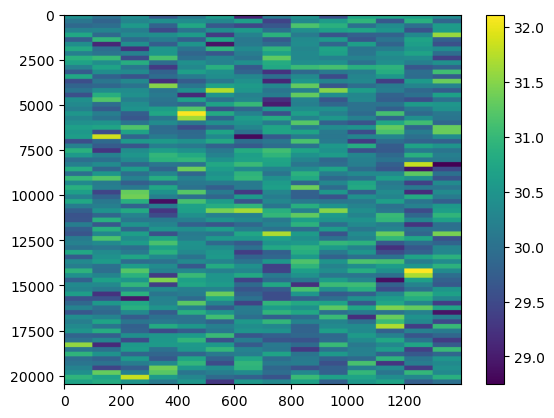

In [21]:
plt.imshow(snr_map, aspect="auto")
plt.colorbar()